# Importing libraries

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV

# Loading datasets

In [2]:
df_contract = pd.read_csv('/datasets/final_provider/contract.csv')
df_internet = pd.read_csv('/datasets/final_provider/internet.csv')
df_personal = pd.read_csv('/datasets/final_provider/personal.csv')
df_phone = pd.read_csv('/datasets/final_provider/phone.csv')

# Exploratory data analysis on the df_contract dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
dtypes: float64(1), object(7)
memory usage: 440.3+ KB
None

Primeros 10 valores de TotalCharges:
0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
5      820.5
6     1949.4
7      301.9
8    3046.05
9    3487.95
Name: TotalCharges, dtype: object

Tipos únicos de valores:
<class 'str'>    7043
Name: TotalCharges, dtype: int64

Valores únicos que no son números:
     11
Name: TotalCharges, dtype: int64

Desc

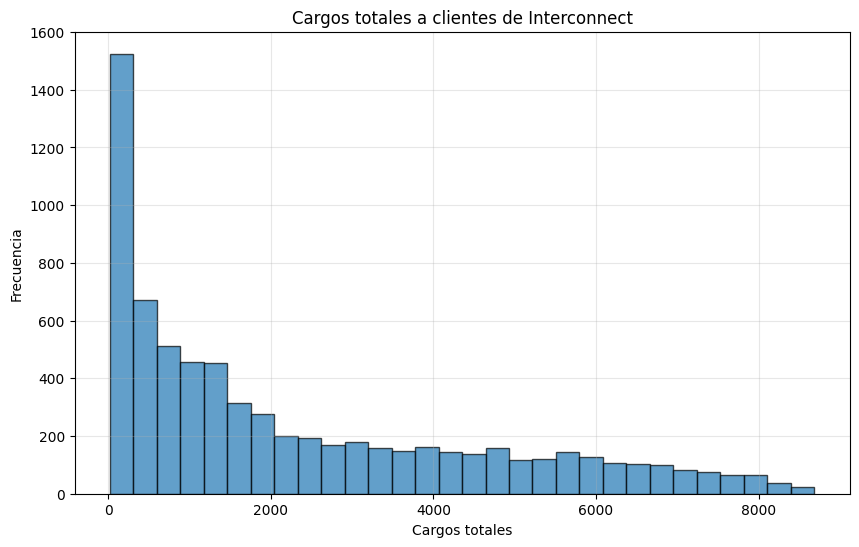


Descripcion estadistica de la columna 'MonthlyCharges':
count    7032.000000
mean       64.798208
std        30.085974
min        18.250000
25%        35.587500
50%        70.350000
75%        89.862500
max       118.750000
Name: MonthlyCharges, dtype: float64


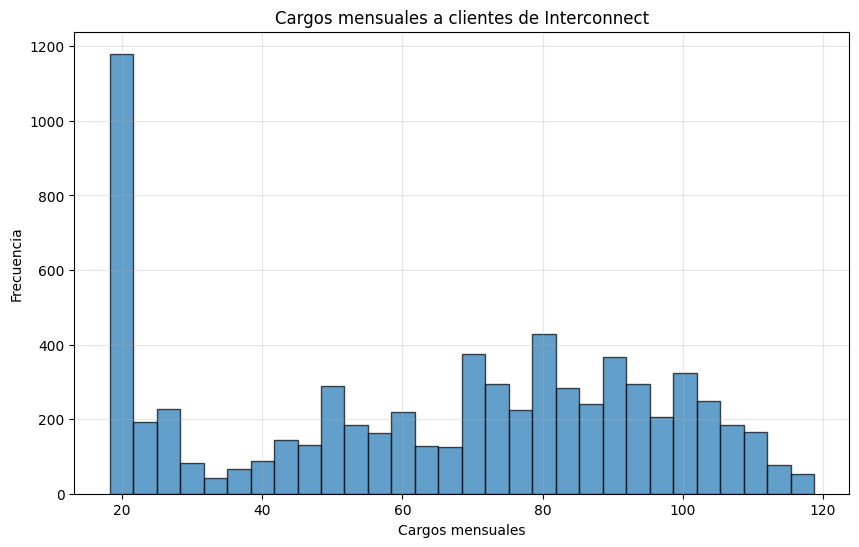


--- Columna: customerID ---
Valores únicos: 7032
Valores: ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

--- Columna: BeginDate ---
Valores únicos: 76
Valores: ['2020-01-01' '2017-04-01' '2019-10-01' '2016-05-01' '2019-09-01'
 '2019-03-01' '2018-04-01' '2019-04-01' '2017-07-01' '2014-12-01'
 '2019-01-01' '2018-10-01' '2015-04-01' '2015-09-01' '2018-01-01'
 '2014-05-01' '2015-10-01' '2014-03-01' '2018-05-01' '2019-11-01'
 '2019-02-01' '2016-01-01' '2017-08-01' '2015-12-01' '2014-02-01'
 '2018-06-01' '2019-12-01' '2017-11-01' '2019-06-01' '2016-04-01'
 '2017-02-01' '2018-12-01' '2014-04-01' '2018-09-01' '2014-11-01'
 '2016-07-01' '2015-02-01' '2018-07-01' '2014-08-01' '2016-03-01'
 '2018-08-01' '2014-10-01' '2015-06-01' '2016-08-01' '2019-05-01'
 '2017-03-01' '2016-02-01' '2017-09-01' '2014-09-01' '2017-12-01'
 '2016-12-01' '2017-06-01' '2015-05-01' '2016-10-01' '2016-09-01'
 '2019-08-01' '2019-07-01' '2017-05-01' '2017-10-01' '2014-07-01'
 '2018-0

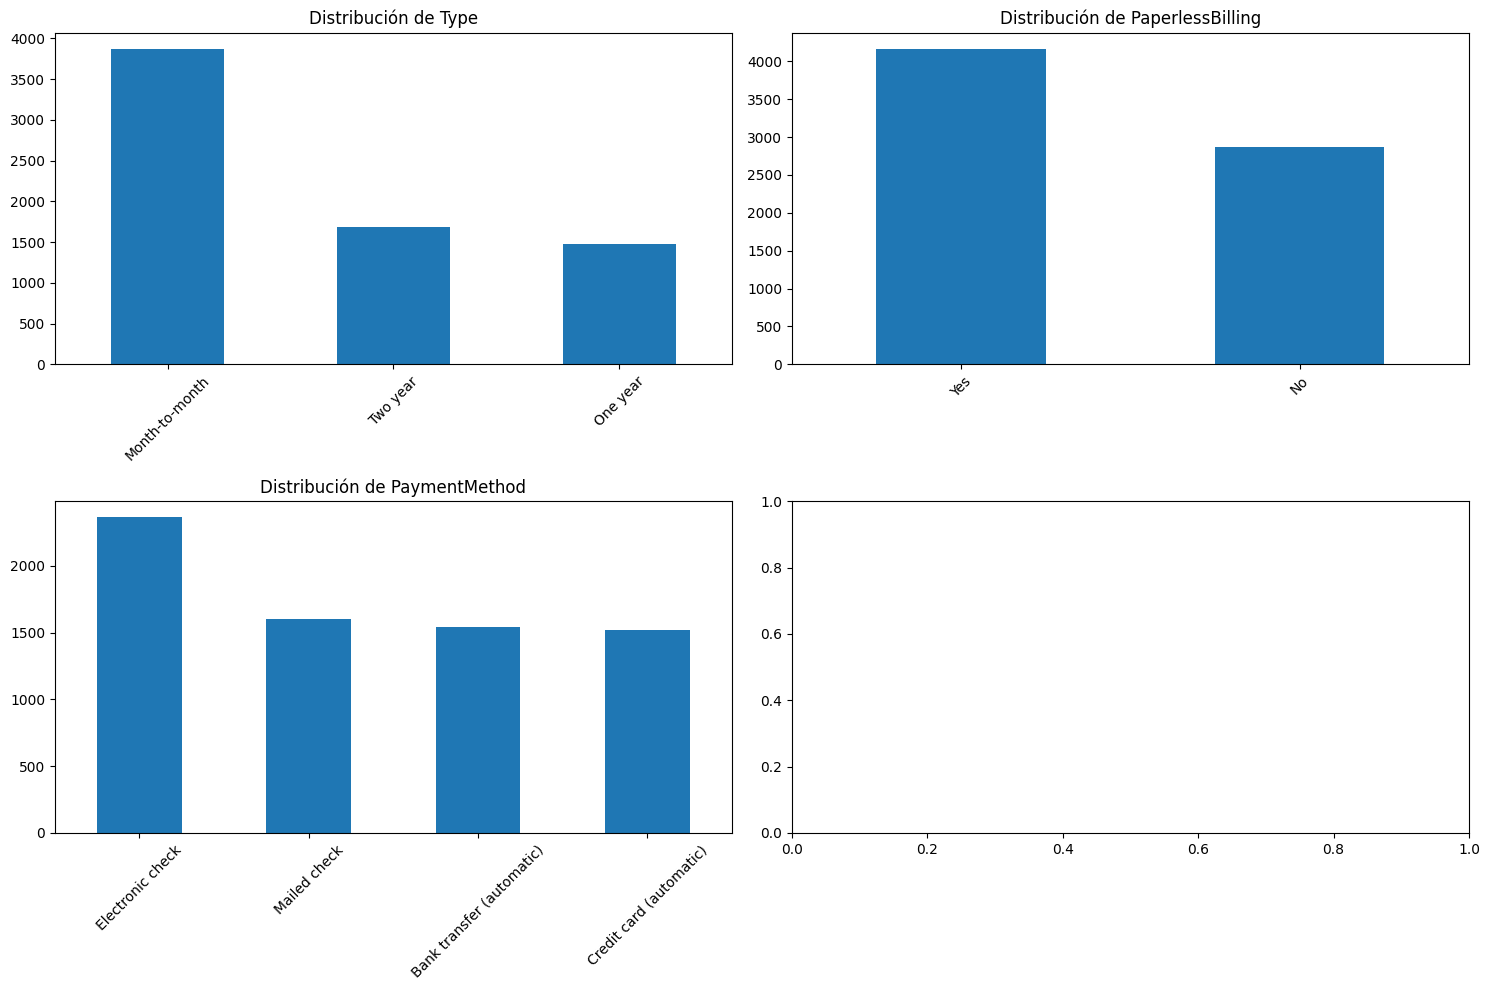

In [ ]:
print(df_contract.info())

print("\nFirst 10 TotalCharges values:")
print(df_contract['TotalCharges'].head(10))

print("\nUnique types of values:")
print(df_contract['TotalCharges'].apply(type).value_counts())

print("\nFirst 10 non-numeric values:")
non_numeric = df_contract['TotalCharges'][pd.to_numeric(df_contract['TotalCharges'], errors='coerce').isna()]
print(non_numeric.head(10))

df_contract['TotalCharges'] = pd.to_numeric(df_contract['TotalCharges'], errors='coerce')
df_contract_clean = df_contract.dropna(subset=['TotalCharges']).copy()

print()
print("Statistical description of column 'TotalCharges':")
print(df_contract_clean['TotalCharges'].describe())

plt.figure(figsize=(10, 6))
plt.hist(df_contract_clean['TotalCharges'], bins=30, edgecolor='black', alpha=0.7)
plt.title('Total charges for Interconnect customers')
plt.xlabel('Total charges')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.show()

print()
print("Statistical description of column 'MonthlyCharges':")
print(df_contract_clean['MonthlyCharges'].describe())

plt.figure(figsize=(10, 6))
plt.hist(df_contract_clean['MonthlyCharges'], bins=30, edgecolor='black', alpha=0.7)
plt.title('Monthly charges for Interconnect customers')
plt.xlabel('Monthly charges')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.show()

categorical_columns_dfcc = df_contract_clean.select_dtypes(include=['object']).columns
for col in categorical_columns_dfcc:
    print(f"\n--- Column: {col} ---")
    print(f"Unique values: {df_contract_clean[col].nunique()}")
    print(f"Values: {df_contract_clean[col].unique()}")

print()
print(df_contract_clean.info())

fig_dfcc, axes_dfcc = plt.subplots(2, 2, figsize=(15, 10))
categorical_vars_dfcc = ['Type', 'PaperlessBilling', 'PaymentMethod']

for i, col in enumerate(categorical_vars_dfcc):
    ax = axes_dfcc[i//2, i%2]
    df_contract_clean[col].value_counts().plot(kind='bar', ax=ax)
    ax.set_title(f'Distribution of {col}')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


# Feature engineering on the df_contract dataset

In [4]:
df_contract_clean['BeginDate'] = pd.to_datetime(df_contract_clean['BeginDate'])

df_contract_clean['BeginYear'] = df_contract_clean['BeginDate'].dt.year
df_contract_clean['BeginMonth'] = df_contract_clean['BeginDate'].dt.month

df_contract_clean = df_contract_clean.drop('BeginDate', axis=1)

In [5]:
df_contract_clean['Churn'] = (df_contract_clean['EndDate'] != 'No').astype(int)

df_contract_clean = df_contract_clean.drop('EndDate', axis=1)

In [6]:
type_mapping = {
    'Month-to-month': 0,  
    'One year': 1,        
    'Two year': 2    
}
df_contract_clean['TypeEncoded'] = df_contract_clean['Type'].map(type_mapping)

df_contract_clean = df_contract_clean.drop('Type', axis=1)

In [7]:
df_contract_clean['PaperlessBillingEncoded'] = (df_contract_clean['PaperlessBilling'] == 'Yes').astype(int)

df_contract_clean = df_contract_clean.drop('PaperlessBilling', axis=1)


In [8]:
payment_method_dummies = pd.get_dummies(df_contract_clean['PaymentMethod'], prefix='Payment', drop_first=True)
df_contract_clean = pd.concat([df_contract_clean, payment_method_dummies], axis=1)

df_contract_clean = df_contract_clean.drop('PaymentMethod', axis=1)


In [9]:
new_order_columns_dfcc = ['customerID', 'BeginYear', 'BeginMonth', 'Churn', 'TypeEncoded', 
                       'PaperlessBillingEncoded', 'Payment_Credit card (automatic)',
                       'Payment_Electronic check', 'Payment_Mailed check',
                       'MonthlyCharges', 'TotalCharges']

df_contract_clean = df_contract_clean[new_order_columns_dfcc]

print(df_contract_clean.info())


<class 'pandas.core.frame.DataFrame'>
Int64Index: 7032 entries, 0 to 7042
Data columns (total 11 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   customerID                       7032 non-null   object 
 1   BeginYear                        7032 non-null   int64  
 2   BeginMonth                       7032 non-null   int64  
 3   Churn                            7032 non-null   int64  
 4   TypeEncoded                      7032 non-null   int64  
 5   PaperlessBillingEncoded          7032 non-null   int64  
 6   Payment_Credit card (automatic)  7032 non-null   uint8  
 7   Payment_Electronic check         7032 non-null   uint8  
 8   Payment_Mailed check             7032 non-null   uint8  
 9   MonthlyCharges                   7032 non-null   float64
 10  TotalCharges                     7032 non-null   float64
dtypes: float64(2), int64(5), object(1), uint8(3)
memory usage: 515.0+ KB
None


# Exploratory analysis on the df_internet dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5517 entries, 0 to 5516
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        5517 non-null   object
 1   InternetService   5517 non-null   object
 2   OnlineSecurity    5517 non-null   object
 3   OnlineBackup      5517 non-null   object
 4   DeviceProtection  5517 non-null   object
 5   TechSupport       5517 non-null   object
 6   StreamingTV       5517 non-null   object
 7   StreamingMovies   5517 non-null   object
dtypes: object(8)
memory usage: 344.9+ KB
None

--- Columna: customerID ---
Valores únicos: 5517
Valores: ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

--- Columna: InternetService ---
Valores únicos: 2
Valores: ['DSL' 'Fiber optic']

--- Columna: OnlineSecurity ---
Valores únicos: 2
Valores: ['No' 'Yes']

--- Columna: OnlineBackup ---
Valores únicos: 2
Valores: ['Yes' 'No']

--- Columna: De

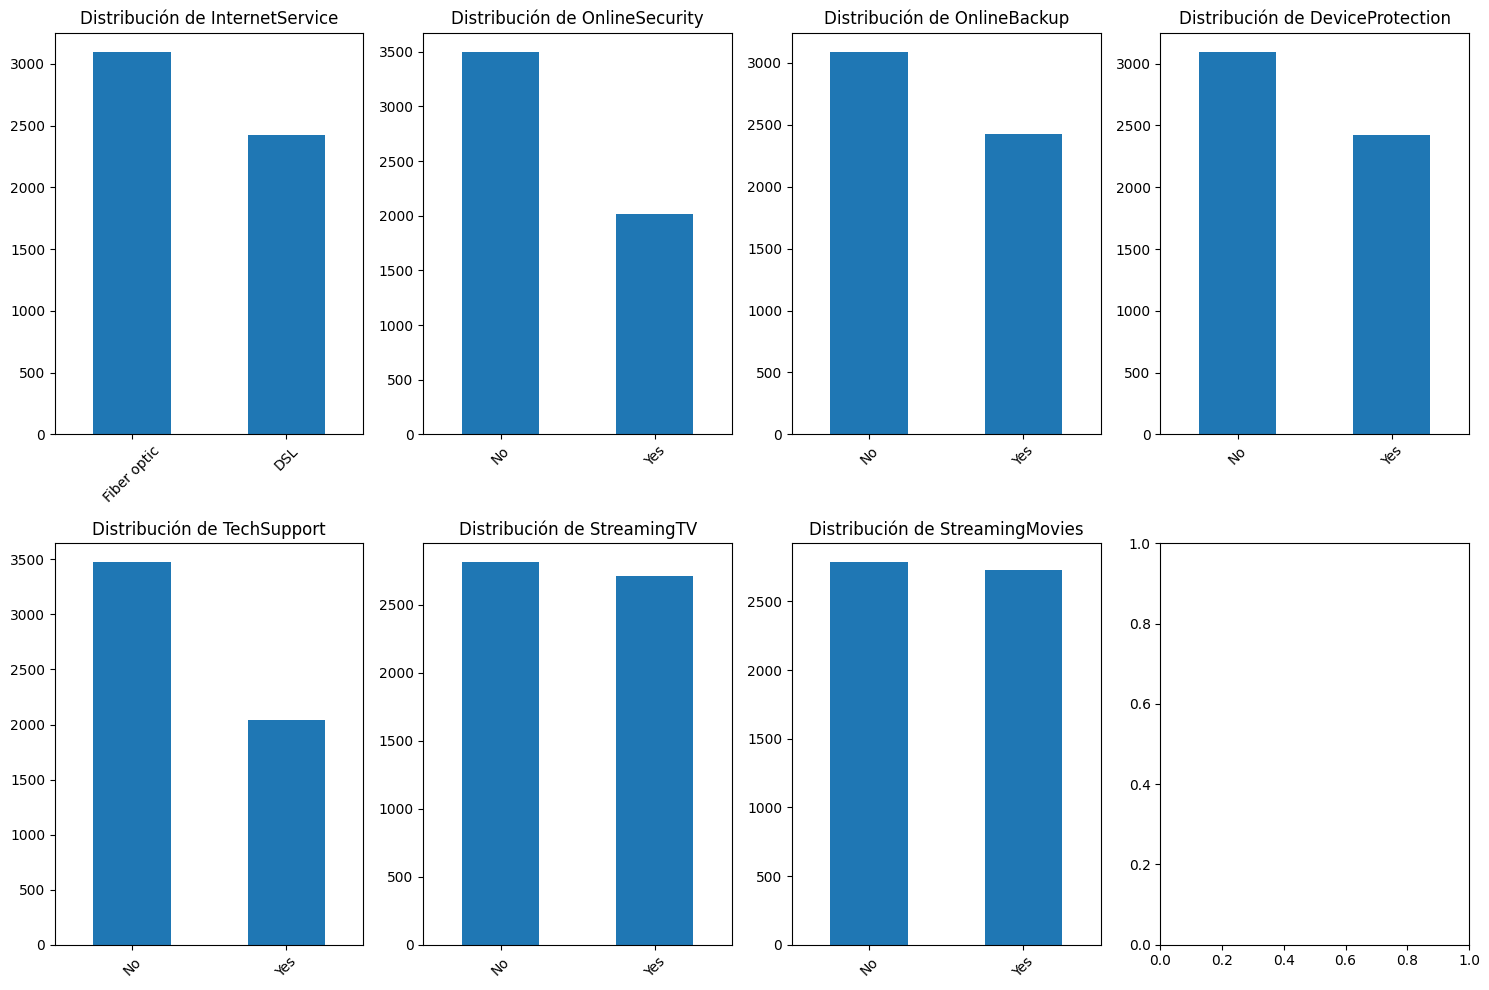

In [ ]:
print(df_internet.info())

categorical_columns_dfi = df_internet.select_dtypes(include=['object']).columns
for col in categorical_columns_dfi:
    print(f"\n--- Column: {col} ---")
    print(f"Unique values: {df_internet[col].nunique()}")
    print(f"Values: {df_internet[col].unique()}")

fig_dfi, axes_dfi = plt.subplots(2, 4, figsize=(15, 10))
categorical_vars_dfi = ['InternetService',
                        'OnlineSecurity', 'OnlineBackup',
                        'DeviceProtection', 'TechSupport',
                        'StreamingTV', 'StreamingMovies']

for i, col in enumerate(categorical_vars_dfi):
    ax = axes_dfi[i//4, i%4]
    df_internet[col].value_counts().plot(kind='bar', ax=ax)
    ax.set_title(f'Distribution of {col}')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Feature engineering on the df_internet dataset

In [11]:
df_internet['FiberOptic'] = (df_internet['InternetService'] == 'Fiber optic').astype(int)

df_internet = df_internet.drop('InternetService', axis=1)


In [12]:
df_internet['OnlineSecurityEncoded'] = (df_internet['OnlineSecurity'] == 'Yes').astype(int)

df_internet = df_internet.drop('OnlineSecurity', axis=1)


In [13]:
df_internet['OnlineBackupEncoded'] = (df_internet['OnlineBackup'] == 'Yes').astype(int)

df_internet = df_internet.drop('OnlineBackup', axis=1)


In [14]:
df_internet['DeviceProtectionEncoded'] = (df_internet['DeviceProtection'] == 'Yes').astype(int)

df_internet = df_internet.drop('DeviceProtection', axis=1)


In [15]:
df_internet['TechSupportEncoded'] = (df_internet['TechSupport'] == 'Yes').astype(int)

df_internet = df_internet.drop('TechSupport', axis=1)


In [16]:
df_internet['StreamingTVEncoded'] = (df_internet['StreamingTV'] == 'Yes').astype(int)

df_internet = df_internet.drop('StreamingTV', axis=1)


In [ ]:
df_internet['StreamingMoviesEncoded'] = (df_internet['StreamingMovies'] == 'Yes').astype(int)

df_internet = df_internet.drop('StreamingMovies', axis=1)

print(df_internet.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5517 entries, 0 to 5516
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   customerID               5517 non-null   object
 1   FiberOptic               5517 non-null   int64 
 2   OnlineSecurityEncoded    5517 non-null   int64 
 3   OnlineBackupEncoded      5517 non-null   int64 
 4   DeviceProtectionEncoded  5517 non-null   int64 
 5   TechSupportEncoded       5517 non-null   int64 
 6   StreamingTVEncoded       5517 non-null   int64 
 7   StreamingMoviesEncoded   5517 non-null   int64 
dtypes: int64(7), object(1)
memory usage: 344.9+ KB
None


# Exploratory analysis on the df_personal dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     7043 non-null   object
 1   gender         7043 non-null   object
 2   SeniorCitizen  7043 non-null   int64 
 3   Partner        7043 non-null   object
 4   Dependents     7043 non-null   object
dtypes: int64(1), object(4)
memory usage: 275.2+ KB
None

--- Columna: customerID ---
Valores únicos: 7043
Valores: ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

--- Columna: Gender ---
Valores únicos: 2
Valores: ['Female' 'Male']

--- Columna: SeniorCitizen ---
Valores únicos: 2
Valores: [0 1]

--- Columna: Partner ---
Valores únicos: 2
Valores: ['Yes' 'No']

--- Columna: Dependents ---
Valores únicos: 2
Valores: ['No' 'Yes']


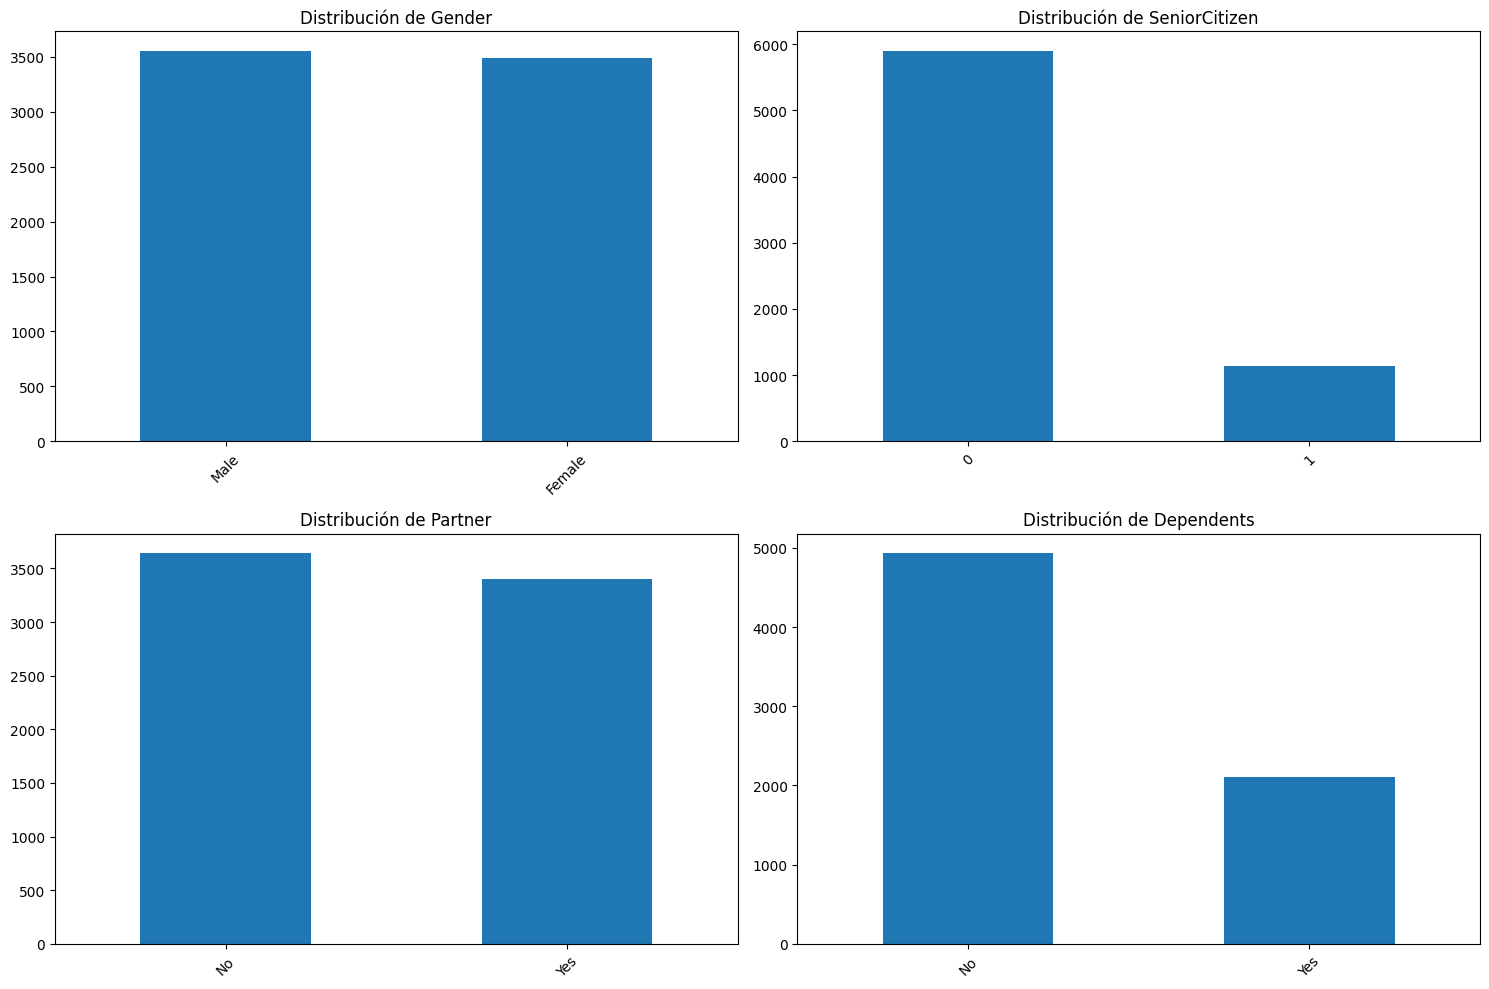

In [ ]:
print(df_personal.info())

df_personal = df_personal.rename(columns={'gender': 'Gender'})

columns_dfp = df_personal.columns
for col in columns_dfp:
    print(f"\n--- Column: {col} ---")
    print(f"Unique values: {df_personal[col].nunique()}")
    print(f"Values: {df_personal[col].unique()}")

fig_dfp, axes_dfp = plt.subplots(2, 2, figsize=(15, 10))
categorical_vars_dfp = ['Gender',
                        'SeniorCitizen', 'Partner',
                        'Dependents']

for i, col in enumerate(categorical_vars_dfp):
    ax = axes_dfp[i//2, i%2]
    df_personal[col].value_counts().plot(kind='bar', ax=ax)
    ax.set_title(f'Distribution of {col}')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Feature engineering on the df_personal dataset

In [19]:
df_personal['Male'] = (df_personal['Gender'] == 'Male').astype(int)

df_personal = df_personal.drop('Gender', axis=1)

In [20]:
df_personal['PartnerEncoded'] = (df_personal['Partner'] == 'Yes').astype(int)

df_personal = df_personal.drop('Partner', axis=1)

In [21]:
df_personal['DependentsEncoded'] = (df_personal['Dependents'] == 'Yes').astype(int)

df_personal = df_personal.drop('Dependents', axis=1)

print(df_personal.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   customerID         7043 non-null   object
 1   SeniorCitizen      7043 non-null   int64 
 2   Male               7043 non-null   int64 
 3   PartnerEncoded     7043 non-null   int64 
 4   DependentsEncoded  7043 non-null   int64 
dtypes: int64(4), object(1)
memory usage: 275.2+ KB
None


In [22]:
new_order_columns_dfp = ['customerID', 'Male', 'SeniorCitizen', 
                          'PartnerEncoded', 'DependentsEncoded']

df_personal = df_personal[new_order_columns_dfp]

print(df_personal.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   customerID         7043 non-null   object
 1   Male               7043 non-null   int64 
 2   SeniorCitizen      7043 non-null   int64 
 3   PartnerEncoded     7043 non-null   int64 
 4   DependentsEncoded  7043 non-null   int64 
dtypes: int64(4), object(1)
memory usage: 275.2+ KB
None


# Exploratory data analysis on the df_phone dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     6361 non-null   object
 1   MultipleLines  6361 non-null   object
dtypes: object(2)
memory usage: 99.5+ KB
None

--- Columna: customerID ---
Valores únicos: 6361
Valores: ['5575-GNVDE' '3668-QPYBK' '9237-HQITU' ... '2234-XADUH' '8361-LTMKD'
 '3186-AJIEK']

--- Columna: MultipleLines ---
Valores únicos: 2
Valores: ['No' 'Yes']


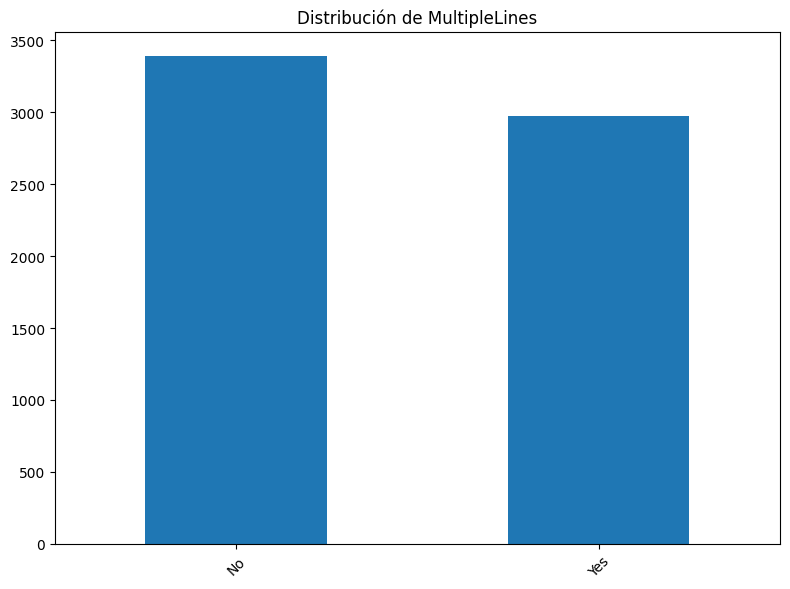

In [ ]:
print(df_phone.info())

columns_dfph = df_phone.columns
for col in columns_dfph:
    print(f"\n--- Column: {col} ---")
    print(f"Unique values: {df_phone[col].nunique()}")
    print(f"Values: {df_phone[col].unique()}")

plt.figure(figsize=(8, 6))
df_phone['MultipleLines'].value_counts().plot(kind='bar')
plt.title('Distribution of MultipleLines')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Feature engineering on the df_phone dataset

In [24]:
df_phone['MultipleLinesEncoded'] = (df_phone['MultipleLines'] == 'Yes').astype(int)

df_phone = df_phone.drop('MultipleLines', axis=1)

print(df_phone.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 2 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   customerID            6361 non-null   object
 1   MultipleLinesEncoded  6361 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 99.5+ KB
None


# Merging of datasets

In [25]:
df_personal_contract_clean = pd.merge(df_personal, df_contract_clean, on='customerID', how='inner')

print(df_personal_contract_clean.info())


<class 'pandas.core.frame.DataFrame'>
Int64Index: 7032 entries, 0 to 7031
Data columns (total 15 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   customerID                       7032 non-null   object 
 1   Male                             7032 non-null   int64  
 2   SeniorCitizen                    7032 non-null   int64  
 3   PartnerEncoded                   7032 non-null   int64  
 4   DependentsEncoded                7032 non-null   int64  
 5   BeginYear                        7032 non-null   int64  
 6   BeginMonth                       7032 non-null   int64  
 7   Churn                            7032 non-null   int64  
 8   TypeEncoded                      7032 non-null   int64  
 9   PaperlessBillingEncoded          7032 non-null   int64  
 10  Payment_Credit card (automatic)  7032 non-null   uint8  
 11  Payment_Electronic check         7032 non-null   uint8  
 12  Payment_Mailed check

In [26]:
df_personal_contract_clean_phone = pd.merge(df_personal_contract_clean, df_phone, on='customerID', how='inner')

print(df_personal_contract_clean_phone.info())


<class 'pandas.core.frame.DataFrame'>
Int64Index: 6352 entries, 0 to 6351
Data columns (total 16 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   customerID                       6352 non-null   object 
 1   Male                             6352 non-null   int64  
 2   SeniorCitizen                    6352 non-null   int64  
 3   PartnerEncoded                   6352 non-null   int64  
 4   DependentsEncoded                6352 non-null   int64  
 5   BeginYear                        6352 non-null   int64  
 6   BeginMonth                       6352 non-null   int64  
 7   Churn                            6352 non-null   int64  
 8   TypeEncoded                      6352 non-null   int64  
 9   PaperlessBillingEncoded          6352 non-null   int64  
 10  Payment_Credit card (automatic)  6352 non-null   uint8  
 11  Payment_Electronic check         6352 non-null   uint8  
 12  Payment_Mailed check

In [27]:
df_complete = pd.merge(df_personal_contract_clean_phone, df_internet, on='customerID', how='inner')

print(df_complete.info())


<class 'pandas.core.frame.DataFrame'>
Int64Index: 4832 entries, 0 to 4831
Data columns (total 23 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   customerID                       4832 non-null   object 
 1   Male                             4832 non-null   int64  
 2   SeniorCitizen                    4832 non-null   int64  
 3   PartnerEncoded                   4832 non-null   int64  
 4   DependentsEncoded                4832 non-null   int64  
 5   BeginYear                        4832 non-null   int64  
 6   BeginMonth                       4832 non-null   int64  
 7   Churn                            4832 non-null   int64  
 8   TypeEncoded                      4832 non-null   int64  
 9   PaperlessBillingEncoded          4832 non-null   int64  
 10  Payment_Credit card (automatic)  4832 non-null   uint8  
 11  Payment_Electronic check         4832 non-null   uint8  
 12  Payment_Mailed check

# Correlation analysis and elimination of correlated columns

In [28]:
numeric_columns = df_complete.select_dtypes(include=[np.number]).columns
df_numeric = df_complete[numeric_columns]

print(df_numeric.corr())

df_complete = df_complete.drop('TotalCharges', axis=1)

print(df_complete.info())

                                     Male  SeniorCitizen  PartnerEncoded  \
Male                             1.000000      -0.010920        0.030315   
SeniorCitizen                   -0.010920       1.000000        0.015682   
PartnerEncoded                   0.030315       0.015682        1.000000   
DependentsEncoded                0.019730      -0.207951        0.421698   
BeginYear                       -0.004839      -0.009722       -0.385640   
BeginMonth                      -0.012017       0.022963       -0.143826   
Churn                           -0.011129       0.113042       -0.169889   
TypeEncoded                      0.003931      -0.119293        0.298875   
PaperlessBillingEncoded         -0.017931       0.108942       -0.012192   
Payment_Credit card (automatic) -0.005260      -0.032029        0.092230   
Payment_Electronic check         0.012725       0.126438       -0.108622   
Payment_Mailed check             0.010317      -0.111510       -0.084730   
MonthlyCharg

# Data splitting

In [32]:
X = df_complete.drop(['customerID', 'Churn'], axis=1)
y = df_complete['Churn']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=12345
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=12345
)

# Data scaling

In [37]:
scaler = StandardScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_val.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

Escalamiento completado!
Forma de X_train_scaled: (2899, 20)


# Class balance analysis of the target variable

In [1]:
print('Target variable class balance:')
print(y.value_counts())

print()
print('Proportion of classes in the target variable:')
print(y.value_counts(normalize=True).round(4) * 100)

Target variable class balance:


NameError: name 'y' is not defined

# Training and evaluation of DummyClassifier

In [ ]:
dummy_model = DummyClassifier(strategy='most_frequent', random_state=12345)

dummy_model.fit(X_train_scaled, y_train)
dummy_probabilities = dummy_model.predict_proba(X_val_scaled)[:, 1]
dummy_predictions = dummy_model.predict(X_val_scaled)

dummy_auc = roc_auc_score(y_val, dummy_probabilities)
print(f"AUC-ROC of DummyClassifier: {dummy_auc:.4f}")

dummy_accuracy = accuracy_score(y_val, dummy_predictions)
print(f"Accuracy of DummyClassifier: {dummy_accuracy:.4f}")

AUC-ROC del DummyClassifier: 0.5000
Exactitud del DummyClassifier: 0.6636


# Training and evaluation of LogisticRegression

In [ ]:
lr_model = LogisticRegression(class_weight='balanced', random_state=12345)

lr_model.fit(X_train_scaled, y_train)
lr_probabilities = lr_model.predict_proba(X_val_scaled)[:, 1]
lr_predictions = lr_model.predict(X_val_scaled)

lr_auc = roc_auc_score(y_val, lr_probabilities)
print(f"AUC-ROC of LogisticRegression: {lr_auc:.4f}")

lr_accuracy = accuracy_score(y_val, lr_predictions)
print(f"Accuracy of LogisticRegression: {lr_accuracy:.4f}")

AUC-ROC de la LogisticRegression: 0.8217
Exactitud de la LogisticRegression: 0.7257


# Training and evaluation of DecisionTreeClassifier

In [ ]:
dtc_model = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=12345,
    max_depth=10,           
    min_samples_split=2,    
    min_samples_leaf=1
)

dtc_model.fit(X_train_scaled, y_train)
dtc_probabilities = dtc_model.predict_proba(X_val_scaled)[:, 1]
dtc_predictions = dtc_model.predict(X_val_scaled)

dtc_auc = roc_auc_score(y_val, dtc_probabilities)
print(f'AUC-ROC of DecisionTreeClassifier: {dtc_auc:.4f}')

dtc_accuracy = accuracy_score(y_val, dtc_predictions)
print(f"Accuracy of DecisionTreeClassifier: {dtc_accuracy:.4f}")

AUC-ROC de DecisionTreeClassifier: 0.7392
Exactitud de DecisionTreeClassifier: 0.6977


# Training and evaluation of RandomForestClassifier

In [ ]:
rfc_model = RandomForestClassifier(class_weight='balanced',
                                   n_estimators=200, max_depth=5, 
                                   random_state=12345)

rfc_model.fit(X_train_scaled, y_train)
rfc_probabilities = rfc_model.predict_proba(X_val_scaled)[:, 1]
rfc_predictions = rfc_model.predict(X_val_scaled)

rfc_auc = roc_auc_score(y_val, rfc_probabilities)
print(f"AUC-ROC of RandomForestClassifier: {rfc_auc:.4f}")

rfc_accuracy = accuracy_score(y_val, rfc_predictions)
print(f"Accuracy of RandomForestClassifier: {rfc_accuracy:.4f}")

AUC-ROC de RandomForestClassifier: 0.8302
Exactitud de RandomForestClassifier: 0.7391


# Training and evaluation of LightGBMClassifier

In [ ]:
lgbmc_model = LGBMClassifier(
    class_weight='balanced',  
    random_state=12345,       
    n_estimators=200,         
    max_depth=5,              
    learning_rate=0.05,
    min_child_samples=20,
    verbose=-1           
)

lgbmc_model.fit(X_train_scaled, y_train)
lgbmc_probabilities = lgbmc_model.predict_proba(X_val_scaled)[:, 1]
lgbmc_predictions = lgbmc_model.predict(X_val_scaled)

lgbmc_auc = roc_auc_score(y_val, lgbmc_probabilities)
print(f"AUC-ROC of LightGBMClassifier: {lgbmc_auc:.4f}")

lgbmc_accuracy = accuracy_score(y_val, lgbmc_predictions)
print(f"Accuracy of LightGBMClassifier: {lgbmc_accuracy:.4f}")

AUC-ROC de LightGBMClassifier: 0.8162
Exactitud de LightGBMClassifier: 0.7422


# Training and evaluation of CatBoostClassifier

In [ ]:
cbc_model = CatBoostClassifier(
    iterations=70,
    learning_rate=0.1,
    depth=4,
    loss_function='Logloss',
    auto_class_weights='Balanced',
    random_state=12345,
    verbose=False
)

cbc_model.fit(X_train_scaled, y_train)
cbc_probabilities = cbc_model.predict_proba(X_val_scaled)[:, 1]
cbc_predictions = cbc_model.predict(X_val_scaled)

cbc_auc = roc_auc_score(y_val, cbc_probabilities)
print(f"AUC-ROC of CatBoostClassifier: {cbc_auc:.4f}")

cbc_accuracy = accuracy_score(y_val, cbc_predictions)
print(f"Accuracy of CatBoostClassifier: {cbc_accuracy:.4f}")

AUC-ROC de LightGBM: 0.8364
Exactitud de LightGBM: 0.7391


# Use of GridSearchCV on CatBoostClassifier

In [ ]:
param_grid = {'iterations':[100, 200, 300],
 'learning_rate':[0.01, 0.1, 0.2],
 'depth':[4, 6, 8], 'l2_leaf_reg': [1, 3, 5, 10] }

grid_search = GridSearchCV(
    estimator=cbc_model,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print("Best parameters found:")
print(grid_search.best_params_)
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_

best_probabilities = best_model.predict_proba(X_val_scaled)[:, 1]
best_auc = roc_auc_score(y_val, best_probabilities)
print(f"AUC-ROC of the best model in validation: {best_auc:.4f}")


Mejores parametros encontrados:
{'depth': 4, 'iterations': 300, 'l2_leaf_reg': 1, 'learning_rate': 0.01}
Mejor puntuación de validación cruzada: 0.8131
AUC-ROC del mejor modelo en validación: 0.8328


# Evaluation of the besst model on the test set

In [ ]:
test_model = cbc_model
test_model.fit(X_train_scaled, y_train)

test_probabilities = test_model.predict_proba(X_test_scaled)[:, 1]
test_predictions = cbc_model.predict(X_test_scaled)

test_auc = roc_auc_score(y_test, test_probabilities)
print(f"AUC-ROC of test model, CatBoostClassifier: {test_auc:.4f}")

test_accuracy = accuracy_score(y_test, test_predictions)
print(f"Accuracy of test model, CatBoostClassifier: {test_accuracy:.4f}")


AUC-ROC del modelo de prueba, CatBoostClassifier: 0.8468
Exactitud del modelo de prueba, CatBoostClassifier: 0.7332


# Conclusion

As expected, the best model for making predictions is CatBoostClassifier. This was anticipated because CatBoostClassifier is a gradient boosting algorithm specialized for categorical features. My manual hyperparameter tuning achieved a better score than GridSearchCV. For this reason, the parameters obtained through manual tuning were selected, and the GridSearchCV results were disregarded.